> **This is a research notebook — one of seven, one per section of the paper.**
>
> For the presentation version, read the two self-contained notebooks in
> [`final/`](../final/) instead: [`1_information_bottleneck.ipynb`](../final/1_information_bottleneck.ipynb) (the whole argument, end to end) and [`2_transformer_extension.ipynb`](../final/2_transformer_extension.ipynb).
>
> This one is the deep dive on the exactly solvable one-neuron model behind the whole effect.

# 1 — Why a tanh network appears to "compress"

**Reproduction of:** Saxe, Bansal, Dapello, Advani, Kolchinsky, Tracey & Cox,
*On the information bottleneck theory of deep learning*, ICLR 2018 / J. Stat. Mech. **2019** 124020.
Section 2, figures 2 and C1.

---

## The claim under test

Shwartz-Ziv & Tishby (2017) reported that deep networks trained by SGD pass through two
phases visible in the **information plane** — a plot of $I(X;T)$ against $I(T;Y)$ for each
hidden layer $T$:

1. a **fitting** phase, in which both $I(X;T)$ and $I(T;Y)$ increase, and
2. a **compression** phase, in which $I(X;T)$ *decreases* while $I(T;Y)$ stays put.

They proposed that the compression phase explains why deep networks generalise.

## The problem this notebook exposes

For a **deterministic** network, $T = f(X)$ with $f$ continuous, the mutual information
between a hidden layer and the input is

$$I(h;X) \;=\; H(h) - H(h \mid X).$$

Given $X$, the activity $h$ is a *delta function* at $f(X)$, so $H(h\mid X) = -\infty$ and

$$\boxed{\,I(h;X) = \infty\,}$$

for any layer with finite $H(h)$ (paper appendix C). Infinity does not move during training.
So **every finite number ever plotted in an information plane comes from an added
assumption** — binning the activity, or pretending noise was added — and the trajectory
may be reporting on that assumption rather than on the network.

This notebook takes the simplest possible case and computes the quantity *exactly*, with
no estimator and no sampling, to see what the assumption alone contributes.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "ibdl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from ibdl import plotting
plotting.use_paper_style()
FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

print("project root:", ROOT)

project root: /home/hooman/Desktop/InfoTheory/Project


## 1.1 The model

Paper figure 2A. A scalar Gaussian input, one weight, one nonlinearity:

$$X \sim \mathcal{N}(0,1), \qquad h = f(w_1 X), \qquad T = \mathrm{bin}(h).$$

Because $T$ is a deterministic function of $X$ **and** $T$ is now discrete,

$$I(T;X) = H(T) - \underbrace{H(T\mid X)}_{=\,0} = H(T) = -\sum_i p_i \log p_i,$$

which is paper equations (1)–(3). The bin probabilities follow from the Gaussian CDF
(equation 4), since for monotone $f$ the event "$h$ lands in bin $i$" is an interval in $X$:

$$p_i = P\big(f^{-1}(b_i)/w_1 \le X < f^{-1}(b_{i+1})/w_1\big)
     = \Phi\!\big(f^{-1}(b_{i+1})/w_1\big) - \Phi\!\big(f^{-1}(b_i)/w_1\big).$$

Everything below is this formula. No networks are trained and no data is sampled.

In [2]:
from ibdl.minimal import bin_probabilities, mi_minimal_model, sweep_weight

# Sanity check: the bin probabilities are a genuine distribution.
for act in ["tanh", "relu", "softplus", "linear", "sigmoid", "softsign"]:
    sums = [bin_probabilities(w, activation=act).sum() for w in [0.1, 1.0, 10.0, 1e3]]
    print(f"{act:9s} sum(p) = {min(sums):.12f} .. {max(sums):.12f}")

tanh      sum(p) = 1.000000000000 .. 1.000000000000
relu      sum(p) = 1.000000000000 .. 1.000000000000
softplus  sum(p) = 1.000000000000 .. 1.000000000000
linear    sum(p) = 1.000000000000 .. 1.000000000000
sigmoid   sum(p) = 1.000000000000 .. 1.000000000000
softsign  sum(p) = 1.000000000000 .. 1.000000000000


## 1.2 Binning is what makes the number finite

Paper figure 2B. The blue curve is $\tanh$; the grey lines are the 30 bin edges evenly
spaced between $-1$ and $1$. The picture explains the whole phenomenon: because $\tanh$
saturates, **a wide range of large net inputs maps into the same end bin**. Once the
weights are large enough that most inputs are saturated, $T$ is essentially a coin flip.

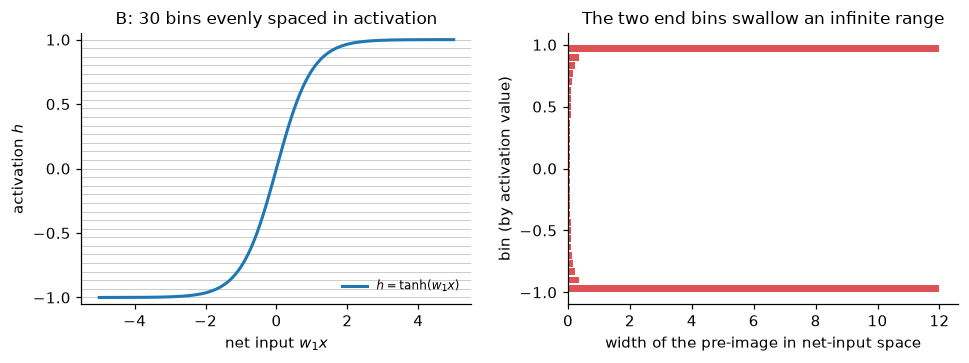

pre-image width of the middle bin : 0.0668
pre-image width of the end bins   : infinite (arctanh(±1) = ±inf)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4))

x = np.linspace(-5, 5, 800)
edges = np.linspace(-1, 1, 31)

ax = axes[0]
ax.plot(x, np.tanh(x), color="#1f77b4", lw=2, label=r"$h=\tanh(w_1 x)$")
for b in edges:
    ax.axhline(b, color="0.75", lw=0.5, zorder=0)
ax.set_xlabel("net input $w_1 x$")
ax.set_ylabel("activation $h$")
ax.set_title("B: 30 bins evenly spaced in activation")
ax.set_ylim(-1.05, 1.05)
ax.legend(loc="lower right")
ax.grid(False)

# How much of the input axis maps into each bin?
ax = axes[1]
inv = np.arctanh(np.clip(edges, -1 + 1e-15, 1 - 1e-15))
widths = np.diff(inv)
centres = 0.5 * (edges[:-1] + edges[1:])
ax.barh(centres, np.clip(widths, 0, 12), height=0.055, color="#d62728", alpha=0.8)
ax.set_xlabel("width of the pre-image in net-input space")
ax.set_ylabel("bin (by activation value)")
ax.set_title("The two end bins swallow an infinite range")
ax.grid(False)

fig.tight_layout()
plotting.save(fig, "fig02B_binning_scheme", FIGDIR)
plt.show()

print("pre-image width of the middle bin :", round(float(widths[15]), 4))
print("pre-image width of the end bins   : infinite (arctanh(±1) = ±inf)")

## 1.3 Figure 2C/2D — the central result

$I(T;X)$ as a function of the weight $w_1$.

* **tanh** (2C): rises, peaks, then **falls back to exactly 1 bit**. For $w_1 \to \infty$
  the unit saturates on almost every input, $T$ concentrates in the two extreme bins, and
  the layer retains just the sign of the input — one fair coin flip.
* **ReLU** (2D): rises **without bound**. Half the inputs ($X<0$) land in the zero bin;
  the other half are Gaussian and spread over ever more bins as $w_1$ grows.

Note the slopes at large $w_1$: linear gains $\log_2 10 \approx 3.32$ bits per decade,
ReLU exactly **half** that, because only half its input distribution is spread out.

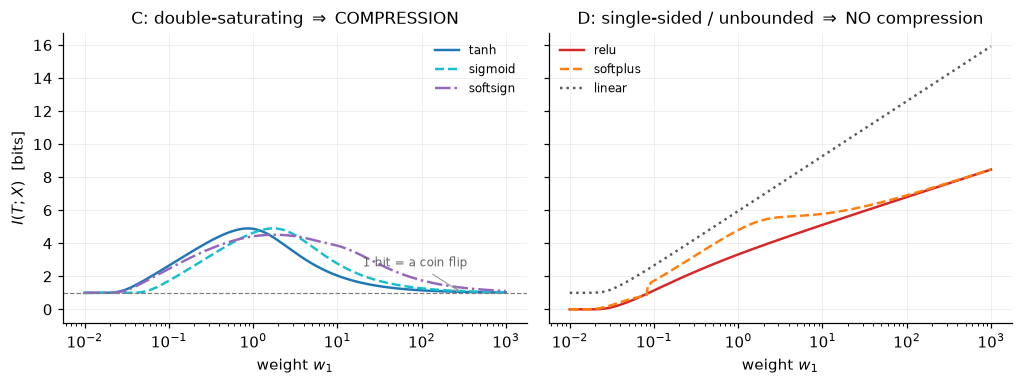

In [4]:
w = np.logspace(-2, 3, 400)

curves = {
    "tanh":     dict(color="#1f77b4", ls="-"),
    "sigmoid":  dict(color="#17becf", ls="--"),
    "softsign": dict(color="#9467bd", ls="-."),
    "relu":     dict(color="#d62728", ls="-"),
    "softplus": dict(color="#ff7f0e", ls="--"),
    "linear":   dict(color="0.35",    ls=":"),
}
mi = {a: sweep_weight(w, activation=a) for a in curves}

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.6), sharey=True)

ax = axes[0]
for a in ["tanh", "sigmoid", "softsign"]:
    ax.plot(w, mi[a], label=a, **curves[a])
ax.axhline(1.0, color="0.5", lw=0.8, ls="--")
ax.annotate("1 bit = a coin flip", xy=(3e2, 1.0), xytext=(2e1, 2.6), fontsize=8,
            color="0.4", arrowprops=dict(arrowstyle="->", color="0.6", lw=0.7))
ax.set_xscale("log")
ax.set_xlabel(r"weight $w_1$")
ax.set_ylabel(r"$I(T;X)$  [bits]")
ax.set_title("C: double-saturating $\\Rightarrow$ COMPRESSION")
ax.legend()

ax = axes[1]
for a in ["relu", "softplus", "linear"]:
    ax.plot(w, mi[a], label=a, **curves[a])
ax.set_xscale("log")
ax.set_xlabel(r"weight $w_1$")
ax.set_title("D: single-sided / unbounded $\\Rightarrow$ NO compression")
ax.legend()

fig.tight_layout()
plotting.save(fig, "fig02CD_minimal_model", FIGDIR)
plt.show()

In [5]:
print("activation   peak I(T;X)   at w1     I(T;X) at w1=1000    verdict")
print("-" * 74)
for a in curves:
    peak, wpk, tail = mi[a].max(), w[mi[a].argmax()], mi[a][-1]
    verdict = "COMPRESSES" if tail < peak - 0.5 else "no compression"
    print(f"{a:11s}  {peak:9.2f}   {wpk:8.2f}   {tail:14.2f}       {verdict}")

print()
d = lambda a: mi_minimal_model(1e4, activation=a) - mi_minimal_model(1e3, activation=a)
print(f"bits gained per decade of w1 at large w1:")
print(f"  linear : {d('linear'):.3f}   (= log2(10) = {np.log2(10):.3f})")
print(f"  relu   : {d('relu'):.3f}   (= half of linear: only X>0 spreads out)")
print(f"  tanh   : {d('tanh'):+.3f}   (saturated: already collapsed to 1 bit)")

activation   peak I(T;X)   at w1     I(T;X) at w1=1000    verdict
--------------------------------------------------------------------------
tanh              4.90       0.88             1.02       COMPRESSES
sigmoid           4.90       1.75             1.04       COMPRESSES
softsign          4.52       1.80             1.11       COMPRESSES
relu              8.46    1000.00             8.46       no compression
softplus          8.47    1000.00             8.47       no compression
linear           15.92    1000.00            15.92       no compression

bits gained per decade of w1 at large w1:


  linear : 3.322   (= log2(10) = 3.322)
  relu   : 1.661   (= half of linear: only X>0 spreads out)
  tanh   : -0.017   (saturated: already collapsed to 1 bit)


### Reading the result

The two panels use *identical* machinery — same input distribution, same bin width, same
exact entropy formula. The only thing that differs is the shape of $f$. So a
"compression phase" is produced or destroyed by the choice of nonlinearity alone.

Why this matters for training: networks are initialised with **small** weights and must
**grow** them to compute anything nonlinear (paper appendix D — a tanh net with tiny
weights is stuck in its linear regime). A tanh network therefore traverses panel C from
left to right during training, and that traversal *is* the reported compression phase.
A ReLU network traverses panel D, and never compresses.

## 1.4 Appendix C — change the bins, change the conclusion

The binning scheme is not part of the network, so it is an arbitrary modelling choice.
The paper tries a different one: instead of bin edges evenly spaced in *activation*,
put them evenly spaced in **net input** and map them through the nonlinearity,

$$b_i \in \tanh\big(\mathrm{linspace}(-50, 50, N)\big),$$

which packs bins tightly into the saturation region rather than wasting them on the
linear part. Measured this way, the same tanh unit **stops compressing** over the range
where the scheme has resolution (figure C1).

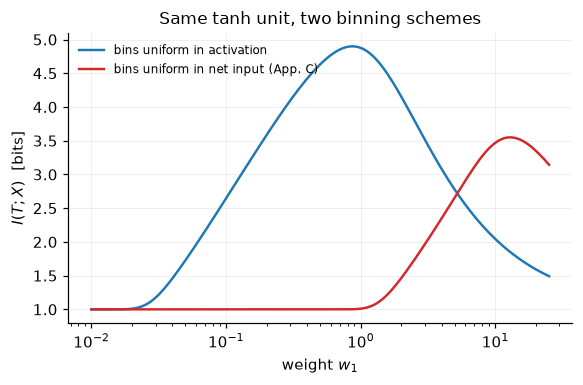

uniform-in-activation : peaks at w1=0.88, then FALLS to 1.49 bits
uniform-in-net-input  : still RISING at w1=25.12 (3.14 bits)


In [6]:
w_c = np.logspace(-2, 1.4, 300)
mi_uniform = sweep_weight(w_c, activation="tanh")
mi_netinput = sweep_weight(w_c, activation="tanh", net_input_binning=True)

fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.plot(w_c, mi_uniform, color="#1f77b4", label="bins uniform in activation")
ax.plot(w_c, mi_netinput, color="#d62728", label="bins uniform in net input (App. C)")
ax.set_xscale("log")
ax.set_xlabel(r"weight $w_1$")
ax.set_ylabel(r"$I(T;X)$  [bits]")
ax.set_title("Same tanh unit, two binning schemes")
ax.legend()
fig.tight_layout()
plotting.save(fig, "figC1_binning_strategy", FIGDIR)
plt.show()

peak_i = mi_uniform.argmax()
print(f"uniform-in-activation : peaks at w1={w_c[peak_i]:.2f}, then FALLS to "
      f"{mi_uniform[-1]:.2f} bits")
print(f"uniform-in-net-input  : still RISING at w1={w_c[-1]:.2f} "
      f"({mi_netinput[-1]:.2f} bits)")

**A caveat the paper does not spell out.** The net-input scheme has its own finite
resolution: its edges only cover net inputs in $[-50, 50]$. Push $w_1$ far past that and
*it* collapses too, for exactly the same reason the uniform scheme does. There is no
"correct" binning — each scheme has a range over which it resolves the representation and
a regime beyond which it reports collapse. That is the point: the curve describes the
measuring instrument at least as much as the network.

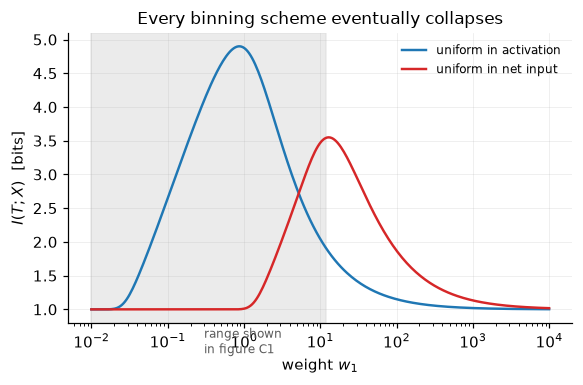

In [7]:
w_far = np.logspace(-2, 4, 300)
fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.plot(w_far, sweep_weight(w_far, activation="tanh"),
        color="#1f77b4", label="uniform in activation")
ax.plot(w_far, sweep_weight(w_far, activation="tanh", net_input_binning=True),
        color="#d62728", label="uniform in net input")
ax.axvspan(1e-2, 12, color="0.85", alpha=0.5, zorder=0)
ax.text(0.3, 0.35, "range shown\nin figure C1", fontsize=8, color="0.35")
ax.set_xscale("log")
ax.set_xlabel(r"weight $w_1$")
ax.set_ylabel(r"$I(T;X)$  [bits]")
ax.set_title("Every binning scheme eventually collapses")
ax.legend()
fig.tight_layout()
plotting.save(fig, "figC1b_binning_far_field", FIGDIR)
plt.show()

## 1.5 Resolution sets the whole vertical scale

One more consequence of $I(h;X)=\infty$: the *number of bins* alone moves the curve up and
down without touching the network. With $P$ distinct inputs and fine enough bins, every
input gets its own code and $I(T;X) = \log_2 P$ — pinned, forever, with no dynamics at all
(paper figure C3, "binning at full machine precision").

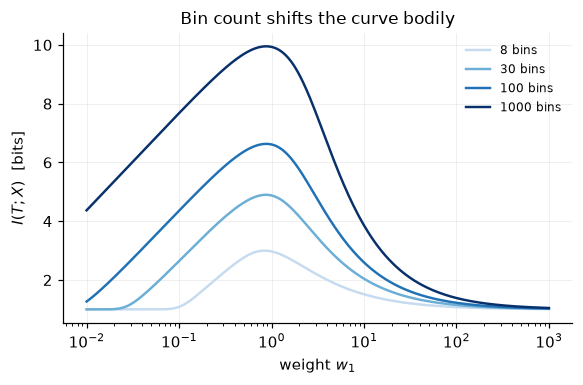

peak I(T;X) versus bin count (same network, same input distribution):
       8 bins -> peak   3.00 bits, asymptote 1.01 bits
      30 bins -> peak   4.90 bits, asymptote 1.02 bits
     100 bins -> peak   6.63 bits, asymptote 1.03 bits


    1000 bins -> peak   9.95 bits, asymptote 1.05 bits


   10000 bins -> peak  13.27 bits, asymptote 1.07 bits


In [8]:
fig, ax = plt.subplots(figsize=(5.4, 3.6))
for n_bins, c in zip([8, 30, 100, 1000], ["#c6dbef", "#6baed6", "#2171b5", "#08306b"]):
    ax.plot(w, sweep_weight(w, activation="tanh", n_bins=n_bins),
            color=c, label=f"{n_bins} bins")
ax.set_xscale("log")
ax.set_xlabel(r"weight $w_1$")
ax.set_ylabel(r"$I(T;X)$  [bits]")
ax.set_title("Bin count shifts the curve bodily")
ax.legend()
fig.tight_layout()
plotting.save(fig, "fig_bincount_sweep", FIGDIR)
plt.show()

print("peak I(T;X) versus bin count (same network, same input distribution):")
for n_bins in [8, 30, 100, 1000, 10000]:
    m = sweep_weight(w, activation="tanh", n_bins=n_bins)
    print(f"  {n_bins:6d} bins -> peak {m.max():6.2f} bits, "
          f"asymptote {m[-1]:.2f} bits")

## Takeaways

1. $I(h;X)=\infty$ for a deterministic continuous network. Any finite information-plane
   number is a property of the **binning/noise assumption** as much as of the network.
2. Under the standard uniform binning, a **double-saturating** nonlinearity (tanh,
   sigmoid, softsign) produces a compression phase as its weights grow; a **single-sided
   or unbounded** one (ReLU, softplus, linear) never does.
3. The effect is **not** an estimation error to be fixed with a better estimator — this
   notebook computed the quantity exactly. It is the definition of the quantity that is at
   issue.
4. Changing the bin edges (App. C) or the bin count turns the compression phase on and
   off while the network is untouched.

Next: [`02_tishby_replication.ipynb`](02_tishby_replication.ipynb) trains the actual
12–10–7–5–4–3–2 network of Shwartz-Ziv & Tishby and shows this mechanism operating in a
real information plane.